In [1]:
import sys
import itertools
sys.path.append('../')
from core import LADTransferTreeBoost, LSTransferTreeBoost, MTransferTreeBoost
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
import numpy as np
from utils import * #only needed for xgboost
import itertools
import matplotlib.pyplot as plt
from baselines import *

In [2]:
from friedman1 import *
seed_list = list(range(7,17))

In [3]:
list(range(7,17))

[7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

In [ ]:
df = pd.DataFrame(columns = ['seed', 'method', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0', 
                                                          'val_rmse', 'val_mae', 'rmse', 'mae'])


v_list = [0.05, 0.1]
source_tree_size_list = [1,2]
target_tree_size_list = [1,2]
k_list = [0.01, 0.05]
m_0_list = [0.5, 0.9]


# --- Step 2: Create full parameter grid ---
param_grid = list(itertools.product(
    v_list,
    source_tree_size_list,
    target_tree_size_list,
    k_list,
    m_0_list
))


# --- Step 2: Create full parameter grid ---
param_grid = list(itertools.product(
    v_list,
    source_tree_size_list,
    target_tree_size_list,
    k_list,
    m_0_list
))

for seed in seed_list:

    
    X_target_test, y_target_test = friedman1(n_samples=1000, add_noise = False, noise_distribution = 'gaussian', n_features=10, random_seed=seed) #do NOT add noise to test set!!!!
    X_target_val, y_target_val = friedman1(n_samples=1000, add_noise = False, noise_distribution = 'gaussian', n_features=10, random_seed=seed + 10) #do NOT add noise to test set!!!!
    X_target_train, y_target_train = friedman1(n_samples=300, add_noise = True, noise_distribution = 'gaussian', n_features=10, random_seed=seed) #add noise to train set
    X_source_train, y_source_train = friedman1_altered(n_samples=1000, add_noise = True, noise_distribution = 'gaussian',
                                                    n_features=10, d=6, shift_seed=seed, random_seed = seed) #also add noise to source (only train here)
    for config in param_grid:
        v, source_tree_size, target_tree_size, k, m_0 = config


        #Test for all methods!!!!

        method = f'LSTransferTreeBoost'
        fiter = LSTransferTreeBoost(epochs=1000, v=v, source_tree_size=source_tree_size, 
                                target_tree_size=target_tree_size, k=k, m_0=m_0)
        fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, val_x=X_target_val, val_y=y_target_val, early_stopping_rounds=8, show_curves=False)
        rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
        val_rmse = fiter.evaluate(X_target_val, y_target_val, metric = 'rmse')
        mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')
        val_mae = fiter.evaluate(X_target_val, y_target_val, metric = 'mae')
        df.loc[len(df)] = [seed, method, v, source_tree_size, target_tree_size, k, m_0, 
                                                          val_rmse, val_mae, rmse, mae]

        method = f'LADTransferTreeBoost'
        fiter = LADTransferTreeBoost(epochs=1000, v=v, source_tree_size=source_tree_size, 
                                target_tree_size=target_tree_size, k=k, m_0=m_0)
        fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, val_x=X_target_val, val_y=y_target_val, early_stopping_rounds=8, show_curves=False)
        rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
        val_rmse = fiter.evaluate(X_target_val, y_target_val, metric = 'rmse')
        mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')
        val_mae = fiter.evaluate(X_target_val, y_target_val, metric = 'mae')
        df.loc[len(df)] = [seed, method, v, source_tree_size, target_tree_size, k, m_0, 
                                                          val_rmse, val_mae, rmse, mae]
        df.to_csv('results/300_gaussian_6.csv')

KeyboardInterrupt: 

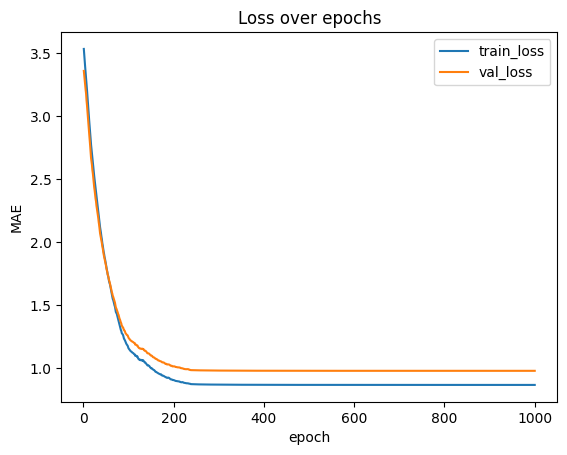

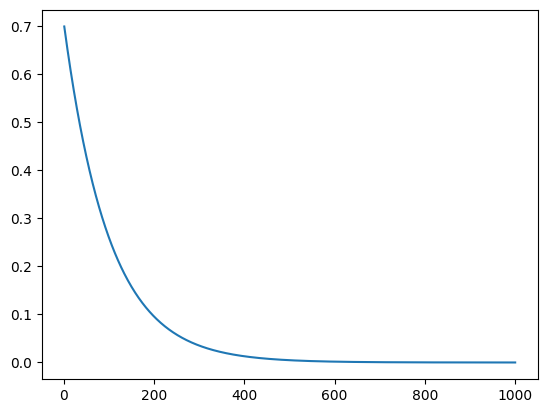

In [ ]:
df = pd.DataFrame(columns = ['seed', 'method',
                                   'v', 'target_tree_size', 'val_rmse', 'val_mae', 'rmse', 'mae'])


v_list = [0.05, 0.1]
source_tree_size_list = [1,2]
target_tree_size_list = [1,2]
k_list = [0.01, 0.05]
m_0_list = [0.5, 0.9]


# --- Step 2: Create full parameter grid ---
param_grid = list(itertools.product(
    v_list,
    source_tree_size_list,
    target_tree_size_list,
    k_list,
    m_0_list
))


# --- Step 2: Create full parameter grid ---
param_grid = list(itertools.product(
    v_list,
    source_tree_size_list,
    target_tree_size_list,
    k_list,
    m_0_list
))

for seed in seed_list:

    
    X_target_test, y_target_test = friedman1(n_samples=1000, add_noise = False, noise_distribution = 'slash', n_features=10, random_seed=seed) #do NOT add noise to test set!!!!
    X_target_val, y_target_val = friedman1(n_samples=1000, add_noise = False, noise_distribution = 'slash', n_features=10, random_seed=seed + 10) #do NOT add noise to test set!!!!
    X_target_train, y_target_train = friedman1(n_samples=300, add_noise = True, noise_distribution = 'slash', n_features=10, random_seed=seed) #add noise to train set
    X_source_train, y_source_train = friedman1_altered(n_samples=1000, add_noise = True, noise_distribution = 'slash',
                                                    n_features=10, d=6, shift_seed=seed, random_seed = seed) #also add noise to source (only train here)
    for config in param_grid:
        v, source_tree_size, target_tree_size, k, m_0 = config


        #Test for all methods!!!!

        method = f'LSTransferTreeBoost'
        fiter = LSTransferTreeBoost(epochs=1000, v=v, source_tree_size=source_tree_size, 
                                target_tree_size=target_tree_size, k=k, m_0=m_0)
        fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, val_x=X_target_val, val_y=y_target_val, early_stopping_rounds=8, show_curves=False)
        rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
        val_rmse = fiter.evaluate(X_target_val, y_target_val, metric = 'rmse')
        mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')
        val_mae = fiter.evaluate(X_target_val, y_target_val, metric = 'mae')
        df.loc[len(df)] = [seed, method, v, target_tree_size, val_rmse, val_mae, rmse, mae]

        method = f'LADTransferTreeBoost'
        fiter = LADTransferTreeBoost(epochs=1000, v=v, source_tree_size=source_tree_size, 
                                target_tree_size=target_tree_size, k=k, m_0=m_0)
        fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, val_x=X_target_val, val_y=y_target_val, early_stopping_rounds=8, show_curves=False)
        rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
        val_rmse = fiter.evaluate(X_target_val, y_target_val, metric = 'rmse')
        mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')
        val_mae = fiter.evaluate(X_target_val, y_target_val, metric = 'mae')
        df.loc[len(df)] = [seed, method, v, target_tree_size, val_rmse, val_mae, rmse, mae]
        df.to_csv('results/300_slash_6.csv')

In [ ]:
print(mae)
print(rmse)

0.9987525883921047
1.2778269395023056
